In [7]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_mps_initializer.datatypes import QuantumState
from qiskit.quantum_info import state_fidelity


def spatial_grid(L, Nx):
    return np.linspace(-L/2, L/2, Nx, endpoint=False)


def thickness_profile_sharp(x, Lambda, duty, d0, h):
    phase = (x % Lambda) / Lambda
    return d0 + h * (phase < duty).astype(float)


def thickness_profile_smooth_periodic(x, Lambda, duty, d0, h, k=40):
    phase = (x % Lambda) / Lambda

    center = duty / 2
    u = phase - center
    u = (u + 0.5) % 1.0 - 0.5

    halfwidth = duty / 2

    pulse = 0.5 * (1 - np.tanh(k * (np.abs(u) - halfwidth)))

    return d0 + h * pulse


def phase_signal(d, n_refr, lam):
    k0 = 2 * np.pi / lam
    return n_refr * k0 * d


def phi_from_f(f):
    alpha = np.sum(f)
    phi = np.sqrt(f / alpha)
    return phi, alpha

In [8]:
# spatial parameters
T = 10e-6

# optical parameters
lam = 630e-9
n_refr = 1.0

# square/smooth profile parameters
Lambda = 2e-6
duty = 0.50
d0 = 100e-9
h = 200e-9
smoothness_k = 20

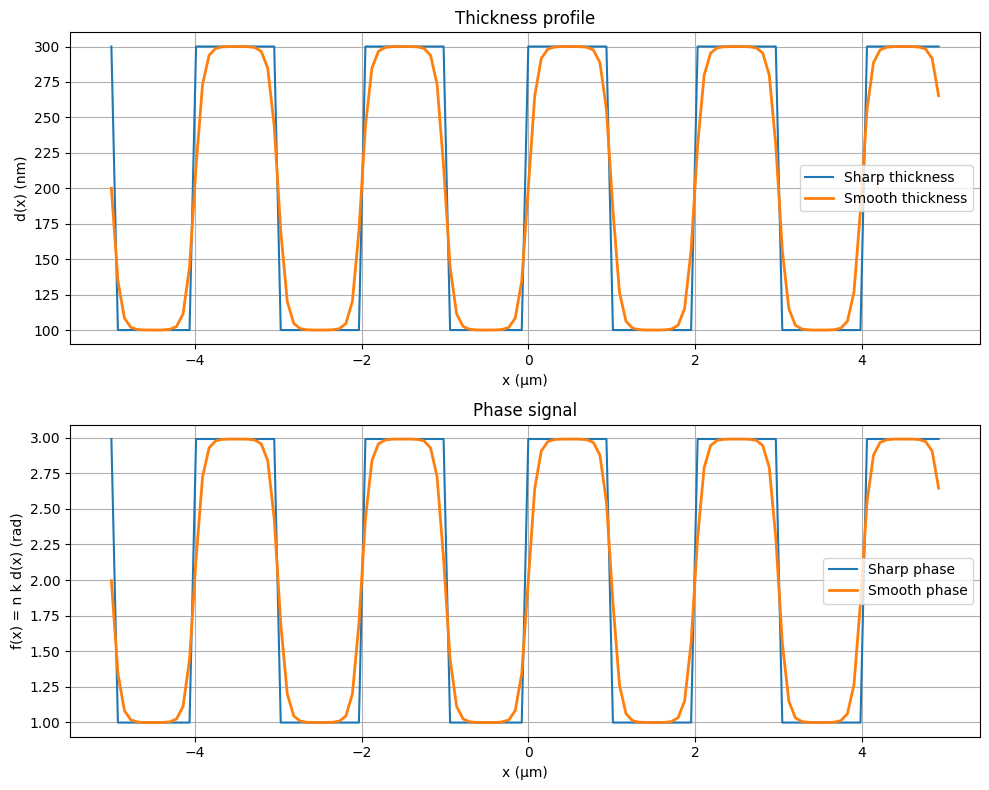

In [9]:
Nx = 128

x = spatial_grid(T, Nx)

d_sharp = thickness_profile_sharp(
    x=x,
    Lambda=Lambda,
    duty=duty,
    d0=d0,
    h=h
)

d_smooth = thickness_profile_smooth_periodic(
    x=x,
    Lambda=Lambda,
    duty=duty,
    d0=d0,
    h=h,
    k=smoothness_k
)

f_sharp = phase_signal(d_sharp, n_refr, lam)
f_smooth = phase_signal(d_smooth, n_refr, lam)

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.plot(x * 1e6, d_sharp * 1e9, label="Sharp thickness", linewidth=1.5)
plt.plot(x * 1e6, d_smooth * 1e9, label="Smooth thickness", linewidth=2)
plt.xlabel("x (µm)")
plt.ylabel("d(x) (nm)")
plt.title("Thickness profile")
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(x * 1e6, f_sharp, label="Sharp phase", linewidth=1.5)
plt.plot(x * 1e6, f_smooth, label="Smooth phase", linewidth=2)
plt.xlabel("x (µm)")
plt.ylabel("f(x) = n k d(x) (rad)")
plt.title("Phase signal")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
sim = AerSimulator(method="statevector")

qubit_range = range(5, 10)
layer_range = range(1, 201)
threshold = 0.99

best_layers = []
best_fidelities = []

for n_qubits in qubit_range:

    Nx = 2**n_qubits

    x = spatial_grid(T, Nx)

    d = thickness_profile_smooth_periodic(
        x=x,
        Lambda=Lambda,
        duty=duty,
        d0=d0,
        h=h,
        k=smoothness_k
    )

    f = phase_signal(d, n_refr, lam)
    phi, _ = phi_from_f(f)

    phi = np.asarray(phi, dtype=complex)
    phi = phi / np.linalg.norm(phi)

    phi_state = QuantumState.from_dense_data(data=phi, normalize=False)

    print(f"\nRunning for {n_qubits} qubits")

    reached_threshold = False

    for L in layer_range:

        U_phi = phi_state.generate_mps_initializer_circuit(
            number_of_layers=L
        )

        qc = QuantumCircuit(n_qubits)
        qc.append(U_phi, range(n_qubits))
        qc.save_statevector()

        tqc = transpile(qc, sim)
        result = sim.run(tqc).result()
        vec_sim = np.array(result.get_statevector(tqc), dtype=complex)

        F = state_fidelity(vec_sim, phi)

        print(f"  Layers = {L}, Fidelity = {F:.6f}")

        if F >= threshold:
            print(f"  ✅ Threshold reached at layer {L}, Fidelity = {F:.6f}")
            best_layers.append(L)
            best_fidelities.append(F)
            reached_threshold = True
            break

    if not reached_threshold:
        print("  ❌ Threshold not reached up to 200 layers")
        best_layers.append(np.nan)
        best_fidelities.append(np.nan)

print("\nSummary")
for q, L_best, F_best in zip(qubit_range, best_layers, best_fidelities):
    print(f"Qubits = {q}, Layer = {L_best}, Fidelity = {F_best}")


Running for 5 qubits
  Layers = 1, Fidelity = 0.989375
  Layers = 2, Fidelity = 0.994576
  ✅ Threshold reached at layer 2, Fidelity = 0.994576

Running for 6 qubits
  Layers = 1, Fidelity = 0.987106
  Layers = 2, Fidelity = 0.994691
  ✅ Threshold reached at layer 2, Fidelity = 0.994691

Running for 7 qubits
  Layers = 1, Fidelity = 0.972376
  Layers = 2, Fidelity = 0.992410
  ✅ Threshold reached at layer 2, Fidelity = 0.992410

Running for 8 qubits
  Layers = 1, Fidelity = 0.970481
  Layers = 2, Fidelity = 0.982775
  Layers = 3, Fidelity = 0.989668
  Layers = 4, Fidelity = 0.981646
  Layers = 5, Fidelity = 0.978673
  Layers = 6, Fidelity = 0.986023
  Layers = 7, Fidelity = 0.987200
  Layers = 8, Fidelity = 0.952642
  Layers = 9, Fidelity = 0.961338
  Layers = 10, Fidelity = 0.970897
  Layers = 11, Fidelity = 0.976769
  Layers = 12, Fidelity = 0.974508
  Layers = 13, Fidelity = 0.970224
  Layers = 14, Fidelity = 0.975527
  Layers = 15, Fidelity = 0.952031
  Layers = 16, Fidelity = 0.93

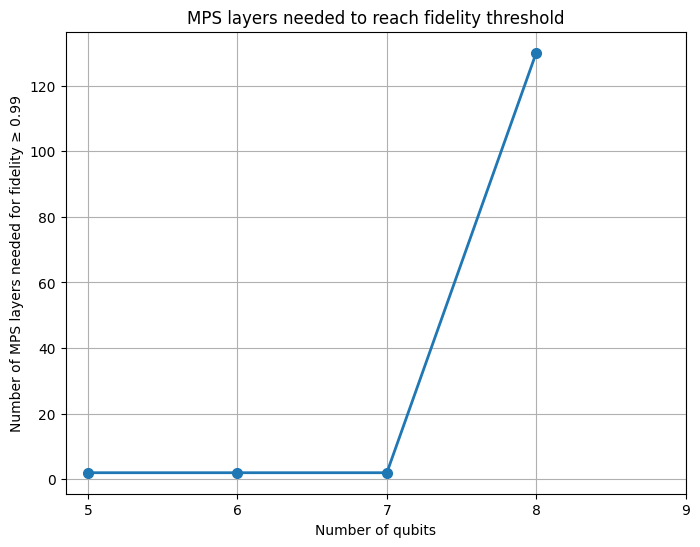

In [13]:
import matplotlib.pyplot as plt
import numpy as np

qubits = list(qubit_range)
layers = np.array(best_layers, dtype=float)

plt.figure(figsize=(8, 6))
plt.plot(qubits, layers, "o-", linewidth=2, markersize=7)

plt.xlabel("Number of qubits")
plt.ylabel(f"Number of MPS layers needed for fidelity ≥ {threshold}")
plt.title("MPS layers needed to reach fidelity threshold")
plt.grid(True)
plt.xticks(qubits)
plt.show()

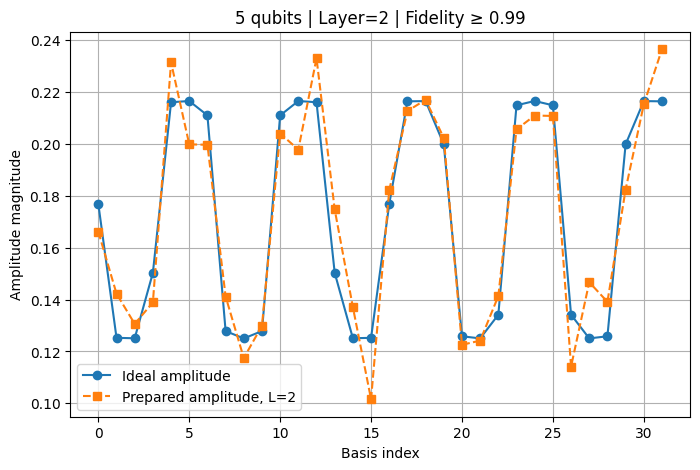

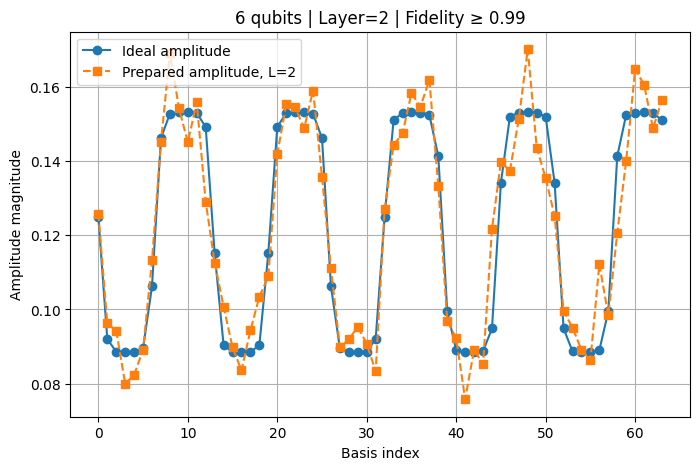

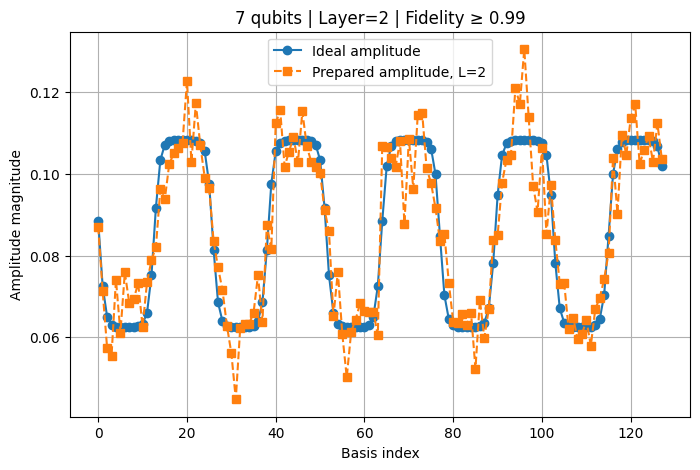

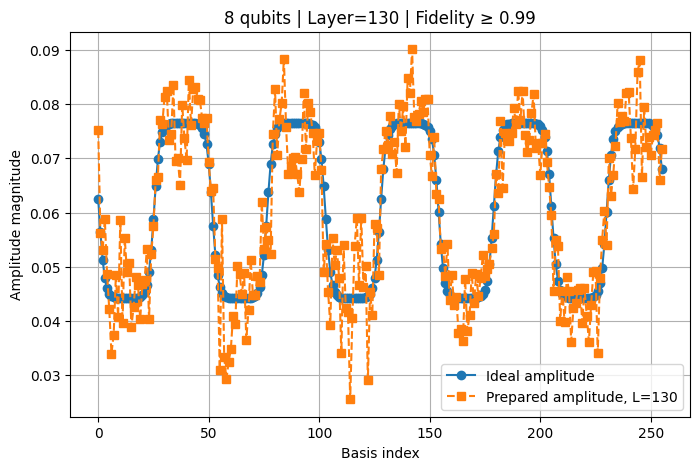

9 qubits: threshold not reached.


In [15]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_mps_initializer.datatypes import QuantumState
import numpy as np
import matplotlib.pyplot as plt

sim = AerSimulator(method="statevector")

for qi, n_qubits in enumerate(qubit_range):

    chosen_layer = best_layers[qi]

    if np.isnan(chosen_layer):
        print(f"{n_qubits} qubits: threshold not reached.")
        continue

    Nx = 2**n_qubits

    # regenerate phi
    x = spatial_grid(T, Nx)

    d = thickness_profile_smooth_periodic(
        x=x,
        Lambda=Lambda,
        duty=duty,
        d0=d0,
        h=h,
        k=smoothness_k
    )

    f = phase_signal(d, n_refr, lam)
    phi, _ = phi_from_f(f)

    phi = np.asarray(phi, dtype=complex)
    phi = phi / np.linalg.norm(phi)

    # prepare state with threshold layer
    phi_state = QuantumState.from_dense_data(data=phi, normalize=False)

    U_phi = phi_state.generate_mps_initializer_circuit(
        number_of_layers=int(chosen_layer)
    )

    qc = QuantumCircuit(n_qubits)
    qc.append(U_phi, range(n_qubits))
    qc.save_statevector()

    tqc = transpile(qc, sim)
    result = sim.run(tqc).result()

    vec_sim = np.array(result.get_statevector(tqc), dtype=complex)

    # remove global phase
    global_phase = np.angle(np.vdot(phi, vec_sim))
    vec_sim_aligned = vec_sim * np.exp(-1j * global_phase)

    amps_ideal = np.abs(phi)
    amps_sim = np.abs(vec_sim_aligned)

    plt.figure(figsize=(8, 5))

    plt.plot(range(Nx), amps_ideal, 'o-', label="Ideal amplitude")
    plt.plot(range(Nx), amps_sim, 's--',
             label=f"Prepared amplitude, L={int(chosen_layer)}")

    plt.xlabel("Basis index")
    plt.ylabel("Amplitude magnitude")

    plt.title(
        f"{n_qubits} qubits | Layer={int(chosen_layer)} | Fidelity ≥ {threshold}"
    )

    plt.legend()
    plt.grid(True)
    plt.show()